In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist #Dígitos manuscritos (70000 muestras)

In [ ]:
(x_train, y_train),(x_test, y_test)= fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
print('Forma de la imagen: ',x_test[0].shape)
print('Forma de x_train', x_train.shape)
print('Forma de x_test', x_test.shape)
print('Total de muestras', (len(y_train)+len(y_test)))
print(y_test.shape)

Forma de la imagen:  (28, 28)
Forma de x_train (60000, 28, 28)
Forma de x_test (10000, 28, 28)
Total de muestras 70000
(10000,)


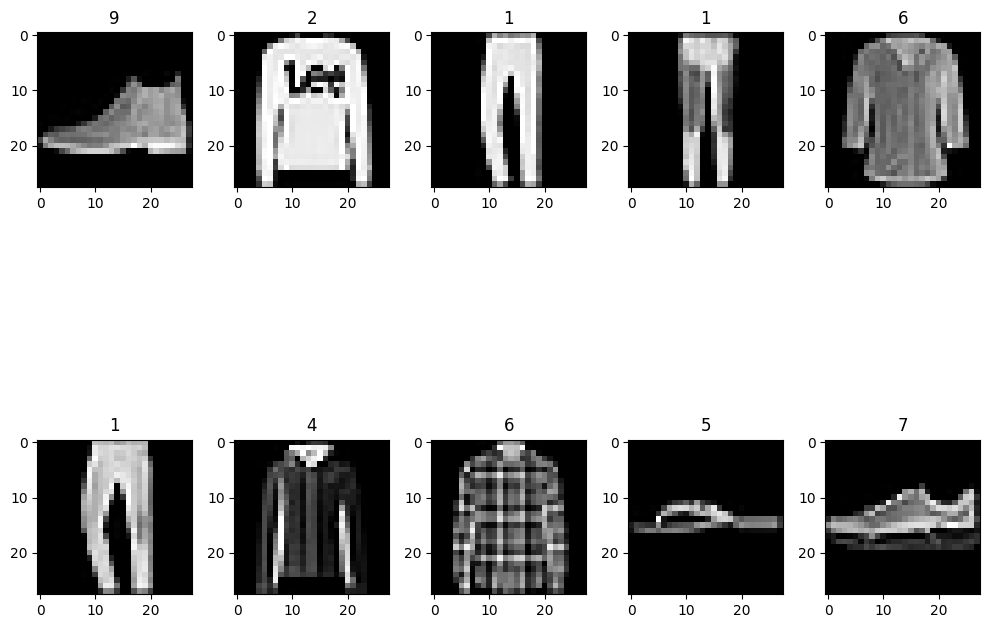

In [ ]:
plt.figure(figsize=(10,10))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_test[i], cmap='gray')
  plt.title(y_test[i])
plt.tight_layout()

In [ ]:
x_train= x_train/255.0
x_test= x_test/255.0
#print(x_test[0])

In [ ]:
model= tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)), #Convertimos la imagen 2D a un vector plano de números (Las capas densas solo admiten imágenes planas)
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=15)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.3669 - loss: 1.9363
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.3750 - loss: 1.9084
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3871 - loss: 1.8808
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.3972 - loss: 1.8542
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4072 - loss: 1.8276
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4144 - loss: 1.8021
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4227 - loss: 1.7773
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4277 - loss: 1.7527
Epoch 9/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4332 - loss: 1.7290
Epoch 10/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4401 - loss: 1.7061
Epoch 11/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4466 - loss: 1.6840
Epoch 12/15
1875/1875 ━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Salida de probabilidades de nuestro softmax [[2.04538053e-04 5.83453476e-01 3.18879485e-02 7.55078197e-02
  2.56758928e-02 3.44495513e-02 8.47208314e-03 1.11533836e-01
  6.95528537e-02 5.92620634e-02]]
Afinando la salida [1]
Etiqueta real 1


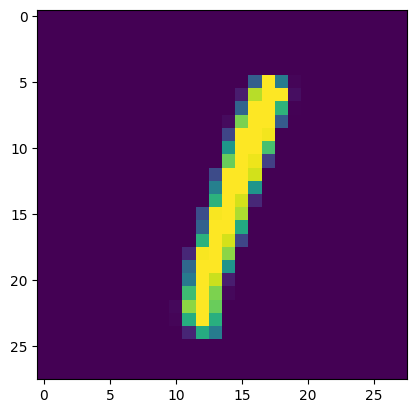

In [ ]:
muestra= x_test[5].reshape(1,28,28)
predict= model.predict(muestra)
print('Salida de probabilidades de nuestro softmax', predict)
print('Afinando la salida', predict.argmax(1))
print('Etiqueta real', y_test[5])
plt.imshow(muestra.reshape(28,28))
